# Time Series Pipeline — U.S. House Results

This notebook builds a time series of U.S. House election results interpolated 
onto the 2026 congressional district boundaries using population-weighted interpolation.

## How to use this notebook
1. Set your county parameters in the Configuration section below
2. Download the MEDSL election files (links in Issue #10) and place in data/raw/election_results/
3. Run all cells top to bottom
4. Outputs will be saved to data/processed/ with your county name in the filename

## Data sources
- Boundary files: data/raw/boundaries/ (already in repo)
- Election results: MEDSL — see Issue #10 for download links
- Census blocks: data/raw/census/ (already in repo)

In [1]:
# =============================================================================
# CONFIGURATION — change these values for your county
# =============================================================================

COUNTY_FIPS = 491
COUNTY_NAME = 'WILLIAMSON'

# Output prefix for saved files
COUNTY_SLUG = COUNTY_NAME.lower()  # e.g. 'travis', 'harris', 'tarrant'

print(f"Running pipeline for: {COUNTY_NAME} County (FIPS: {COUNTY_FIPS})")

Running pipeline for: WILLIAMSON County (FIPS: 491)


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import zipfile
import os

print("Libraries loaded")

Libraries loaded


## Step 1 — Load boundary files

We need three boundary files:
- 2020 precinct boundaries (for 2016, 2018, 2020 election cycles)
- 2022 precinct boundaries (for 2022 election cycle)
- 2024 precinct boundaries (for 2024 election cycle)

All boundary files cover all Texas counties — we filter to our county using CNTY.

In [4]:
# Check what districts Williamson County touches
print(f"2020 precincts: {len(precincts_2020)}")
print(f"Sample PCTKEYs 2020: {sorted(precincts_2020['PCTKEY'].values)[:10]}")
print(f"\n2022 precincts: {len(precincts_2022)}")
print(f"Sample PCTKEYs 2022: {sorted(precincts_2022['PCTKEY'].values)[:10]}")

2020 precincts: 94
Sample PCTKEYs 2020: ['4910119', '4910122', '4910135', '4910138', '4910140', '4910145', '4910146', '4910147', '4910149', '4910150']

2022 precincts: 163
Sample PCTKEYs 2022: ['4910116', '4910117', '4910118', '4910119', '4910122', '4910123', '4910135', '4910136', '4910138', '4910139']


In [3]:
# =============================================================================
# STEP 1 — Load boundary files
# =============================================================================

# 2020 precinct boundaries
precincts_2020 = gpd.read_file('zip://../data/raw/boundaries/precincts20g_2020.zip!Precincts20G_2020.shp')
precincts_2020 = precincts_2020[precincts_2020['CNTY'] == COUNTY_FIPS].copy()
print(f"2020 precincts: {len(precincts_2020)}")

# 2022 precinct boundaries
precincts_2022 = gpd.read_file('zip://../data/raw/boundaries/precincts22g.zip!Precincts22G.shp')
precincts_2022 = precincts_2022[precincts_2022['CNTY'] == COUNTY_FIPS].copy()
print(f"2022 precincts: {len(precincts_2022)}")

# 2024 precinct boundaries
precincts_2024 = gpd.read_file('zip://../data/raw/boundaries/precincts24g.zip!Precincts24G.shp')
precincts_2024 = precincts_2024[precincts_2024['CNTY'] == COUNTY_FIPS].copy()
print(f"2024 precincts: {len(precincts_2024)}")

2020 precincts: 94
2022 precincts: 163
2024 precincts: 164


## Step 2 — Load 2026 congressional district boundaries

These are the target geography — the new district boundaries we want to 
translate historical results onto.

In [5]:
# =============================================================================
# STEP 2 — Load 2026 congressional district boundaries
# =============================================================================

districts = gpd.read_file('zip://../data/raw/boundaries/PLANC2333.zip!PLANC2333/PLANC2333.shp')
print(f"Total 2026 districts: {len(districts)}")
print(f"Columns: {list(districts.columns)}")

print(f"\nDistricts CRS: {districts.crs}")
print(f"Precincts CRS: {precincts_2020.crs}")

Total 2026 districts: 38
Columns: ['District', 'geometry']

Districts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Precincts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4

## Step 3 — Load census block population data

Census blocks are the bridge between precinct boundaries and district boundaries.
Each block has an exact population count and sits entirely within one precinct 
and one district — allowing us to calculate population-weighted splits.

We use 2020 Census blocks for all election cycles (most recent available).

In [7]:
# =============================================================================
# STEP 3 — Load census block population data
# =============================================================================

blocks = gpd.read_file('zip://../data/raw/census/Blocks.zip!Blocks.shp')
blocks = blocks[blocks['CNTY'] == str(COUNTY_FIPS)].copy()
print(f"Census blocks: {len(blocks)}")

# Load population counts
pop = pd.read_csv('../data/raw/census/Blocks_Pop.txt', dtype={'SCTBKEY': str})
pop = pop[pop['SCTBKEY'].str.startswith('48' + str(COUNTY_FIPS))].copy()
print(f"Population records: {len(pop)}")

# Join population to blocks
blocks = blocks.merge(pop[['SCTBKEY', 'total']], on='SCTBKEY', how='left')
blocks['total'] = blocks['total'].fillna(0)
print(f"Total population: {blocks['total'].sum():,.0f}")

Census blocks: 8997
Population records: 8997
Total population: 609,017


## Step 4 — Build weights tables

We build one weights table per precinct boundary version:
- 2020 weights: used for 2016, 2018, and 2020 election cycles
- 2022 weights: used for 2022 election cycle
- 2024 weights: used for 2024 election cycle

Each weights table tells us what fraction of each precinct's population
falls inside each 2026 congressional district.

In [8]:
# =============================================================================
# STEP 4 — Build weights tables
# =============================================================================

def build_weights_table(precincts, districts, blocks, label):
    """
    Build a population-weighted interpolation table for a given set of 
    precinct boundaries intersected with 2026 congressional districts.
    
    Parameters:
        precincts: GeoDataFrame of precinct boundaries
        districts: GeoDataFrame of 2026 congressional district boundaries
        blocks: GeoDataFrame of census blocks with population counts
        label: string label for print statements (e.g. '2020')
    
    Returns:
        DataFrame with columns: old_precinct_id, new_district_id, 
                                fragment_population, weight
    """
    
    # Reproject all to same CRS
    districts_proj = districts.to_crs(precincts.crs)
    blocks_proj = blocks.to_crs(precincts.crs)
    
    # Tag each block with its precinct
    blocks_with_precinct = gpd.sjoin(
        blocks_proj,
        precincts[['PCTKEY', 'geometry']],
        how='left',
        predicate='intersects'
    )
    blocks_with_precinct = blocks_with_precinct.drop(columns=['index_right'])
    
    # Tag each block with its district
    blocks_with_both = gpd.sjoin(
        blocks_with_precinct,
        districts_proj[['District', 'geometry']],
        how='left',
        predicate='intersects'
    )
    
    # Calculate fragment populations
    fragments = blocks_with_both.groupby(
        ['PCTKEY', 'District']
    )['total'].sum().reset_index()
    fragments.columns = ['old_precinct_id', 'new_district_id', 'fragment_population']
    
    # Calculate weights
    precinct_totals = fragments.groupby('old_precinct_id')['fragment_population'].sum()
    fragments['precinct_total'] = fragments['old_precinct_id'].map(precinct_totals)
    fragments['weight'] = fragments['fragment_population'] / fragments['precinct_total']
    
    # Validate
    weight_sums = fragments.groupby('old_precinct_id')['weight'].sum()
    valid = weight_sums[weight_sums.round(6) != 1.0]
    print(f"{label} weights table: {len(fragments)} rows")
    print(f"{label} weight validation — precincts not summing to 1.0: {len(valid)}")
    
    return fragments

# Build weights tables
weights_2020 = build_weights_table(precincts_2020, districts, blocks, '2020')
weights_2022 = build_weights_table(precincts_2022, districts, blocks, '2022')
weights_2024 = build_weights_table(precincts_2024, districts, blocks, '2024')

2020 weights table: 173 rows
2020 weight validation — precincts not summing to 1.0: 0
2022 weights table: 277 rows
2022 weight validation — precincts not summing to 1.0: 0
2024 weights table: 278 rows
2024 weight validation — precincts not summing to 1.0: 0


## Step 5 — Save weights tables

In [9]:
# =============================================================================
# STEP 5 — Save weights tables
# =============================================================================

weights_2020.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2020.csv', index=False)
weights_2022.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2022.csv', index=False)
weights_2024.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2024.csv', index=False)

print(f"Saved {COUNTY_SLUG}_population_weights_2020.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2022.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2024.csv")

Saved williamson_population_weights_2020.csv
Saved williamson_population_weights_2022.csv
Saved williamson_population_weights_2024.csv


## Step 6 — Load election results

We load U.S. House precinct-level results from MEDSL for each election cycle.
Each file covers all Texas counties — we filter to our county using county_name.

Note on 2016: the file uses different column names (state_postal, party) 
compared to later years (state_po, party_simplified).

Note on 2024: MEDSL uses 227xxxx prefix for Travis County precinct IDs 
instead of 453xxxx. We correct this before matching to boundary files.

In [11]:
# =============================================================================
# STEP 6 — Load election results
# =============================================================================

def load_medsl(path, sep, county_name, year):
    """Load and filter MEDSL election results for a given county and year."""
    df = pd.read_csv(path, sep=sep, dtype={'precinct': str, 'county_fips': str}, 
                     low_memory=False)
    
    # Filter to county and House races
    county = df[df['county_name'] == county_name].copy()
    
    # Filter to House races
    if 'dataverse' in county.columns:
        house = county[county['dataverse'] == 'HOUSE'].copy()
    else:
        house = county[county['office'].str.upper() == 'US HOUSE'].copy()
    
    # Construct PCTKEY
    if year == 2016:
        house['PCTKEY'] = house['precinct']
    elif year == 2024:
        house['PCTKEY'] = house['precinct'].str.split('_').str[0].str.replace('^227', '453', regex=True)
    else:
        house['PCTKEY'] = house['precinct'].str.split('_').str[0]
    
    # Strip letter suffixes from split precincts
    house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)

    # Standardize party column
    if 'party_simplified' in house.columns:
        house = house.rename(columns={'party_simplified': 'party'})
    
    print(f"{year}: {len(house)} rows, {house['PCTKEY'].nunique()} unique precincts")
    return house

results_2016 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2016.tab', ',', COUNTY_NAME.title() + ' County', 2016)
results_2018 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2018.csv', ',', COUNTY_NAME, 2018)
results_2020 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2020.csv', ',', COUNTY_NAME, 2020)
results_2022 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2022.csv', ',', COUNTY_NAME, 2022)
results_2024 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2024.csv', ',', COUNTY_NAME, 2024)

2016: 591 rows, 196 unique precincts
2018: 654 rows, 203 unique precincts
2020: 590 rows, 202 unique precincts
2022: 520 rows, 263 unique precincts
2024: 812 rows, 274 unique precincts


## Step 7 — Run interpolation

For each election cycle we apply the appropriate weights table to the 
election results to produce interpolated vote totals by 2026 district.

- 2016, 2018, 2020: use 2020 weights table
- 2022: use 2022 weights table
- 2024: use 2024 weights table

In [16]:
# =============================================================================
# STEP 7 — Run interpolation
# =============================================================================

def interpolate(results, weights, year):
    """
    Apply population weights to precinct-level election results to produce
    estimated vote totals by 2026 congressional district.
    
    Parameters:
        results: DataFrame of precinct-level election results
        weights: DataFrame of population weights
        year: int election year
    
    Returns:
        DataFrame with columns: year, new_district_id, candidate, party, estimated_votes
    """
    
    # Merge results with weights
    merged = results.merge(
        weights[['old_precinct_id', 'new_district_id', 'weight']],
        left_on='PCTKEY',
        right_on='old_precinct_id',
        how='inner'
    )
    
    # Apply weights to vote counts
    merged['estimated_votes'] = merged['votes'].astype(float) * merged['weight']
    
    # Aggregate by district and candidate
    result = merged.groupby(
        ['new_district_id', 'candidate', 'party']
    )['estimated_votes'].sum().reset_index()
    
    result['year'] = year
    
    # Validation — compare total votes before and after
    original_total = results['votes'].astype(float).sum()
    interpolated_total = result['estimated_votes'].sum()
    diff = abs(original_total - interpolated_total)
    print(f"{year}: original={original_total:,.0f}, interpolated={interpolated_total:,.0f}, diff={diff:.2f}")
    
    return result

# Run interpolation for each cycle
interp_2016 = interpolate(results_2016, weights_2020, 2016)
interp_2018 = interpolate(results_2018, weights_2020, 2018)
interp_2020 = interpolate(results_2020, weights_2020, 2020)
interp_2022 = interpolate(results_2022, weights_2022, 2022)
interp_2024 = interpolate(results_2024, weights_2024, 2024)

2016: original=333,197, interpolated=198,726, diff=134471.00
2018: original=337,109, interpolated=206,689, diff=130420.00
2020: original=450,966, interpolated=281,014, diff=169952.00
2022: original=268,831, interpolated=158,684, diff=110147.00
2024: original=458,386, interpolated=0, diff=458386.00


In [17]:
# Check 2024 Williamson precinct format
print("2024 PCTKEY sample:")
print(results_2024['PCTKEY'].head(10).tolist())

# Check 2020 match rate
matched = set(results_2020['PCTKEY'].unique()) & set(weights_2020['old_precinct_id'].unique())
unmatched = set(results_2020['PCTKEY'].unique()) - set(weights_2020['old_precinct_id'].unique())
print(f"\n2020 matched: {len(matched)}, unmatched: {len(unmatched)}")
print(f"Sample unmatched: {sorted(unmatched)[:10]}")

2024 PCTKEY sample:
['BLAIRSVILLE 1', 'BLAIRSVILLE 2', 'BLAIRSVILLE 3', 'BLAIRSVILLE 4', 'BLAIRSVILLE 5', 'CARTERVILLE 1', 'CARTERVILLE 2', 'CARTERVILLE 3', 'CARTERVILLE 4', 'CARTERVILLE 5']

2020 matched: 94, unmatched: 108
Sample unmatched: ['1-1', '1-2', '1-3', '1-4', '1-5', '10-1', '10-2', '10-3', '11-1', '11-2']


## Step 8 — Combine into time series and save

In [15]:
# =============================================================================
# STEP 8 — Combine into time series and save
# =============================================================================

time_series = pd.concat([
    interp_2016, interp_2018, interp_2020, interp_2022, interp_2024
], ignore_index=True)

time_series = time_series[['year', 'new_district_id', 'candidate', 'party', 'estimated_votes']]
time_series['party'] = time_series['party'].str.upper()
party_map = {'DEMOCRATIC': 'DEMOCRAT', 'GREEN': 'OTHER'}
time_series['party'] = time_series['party'].replace(party_map)

time_series.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"\nFinal time series: {len(time_series)} rows")
print(time_series.groupby(['year', 'party'])['estimated_votes'].sum().unstack().round(0))

NameError: name 'output_path' is not defined

In [36]:
# Preview the time series
print(time_series.head(20).to_string())
print(f"\nSample — District 37 across all years:")
print(time_series[time_series['new_district_id'] == 37][['year', 'candidate', 'party', 'estimated_votes']].to_string())

    year  new_district_id     candidate        party  estimated_votes
0   2016               10        Cadien     DEMOCRAT      7588.427102
1   2016               10          Diaz        OTHER       407.809135
2   2016               10       Doggett     DEMOCRAT       122.967973
3   2016               10        Flores   REPUBLICAN      4171.529037
4   2016               10        Kelsey  LIBERTARIAN       869.414715
5   2016               10         Loewe  LIBERTARIAN       965.787705
6   2016               10         Matta     DEMOCRAT      8316.084554
7   2016               10        McCaul   REPUBLICAN      8107.589664
8   2016               10       Narvaiz   REPUBLICAN        16.691792
9   2016               10     Patterson  LIBERTARIAN       874.826890
10  2016               10  Schneiderman  LIBERTARIAN      2952.854448
11  2016               10         Smith  LIBERTARIAN         6.278564
12  2016               10         Smith   REPUBLICAN      7619.695208
13  2016            

In [37]:
# Standardize party labels
party_map = {
    'DEMOCRATIC': 'DEMOCRAT',
    'GREEN': 'OTHER',
}
time_series['party'] = time_series['party'].replace(party_map)

print(time_series['party'].unique())

['DEMOCRAT' 'OTHER' 'REPUBLICAN' 'LIBERTARIAN']


In [38]:
time_series.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"\nFinal time series: {len(time_series)} rows")
print(time_series.groupby(['year', 'party'])['estimated_votes'].sum().unstack().round(0))

Saved: ../data/processed/travis_house_time_series.csv

Final time series: 355 rows
party  DEMOCRAT  LIBERTARIAN   OTHER  REPUBLICAN
year                                            
2016   279802.0      24614.0  5343.0    149963.0
2018   340345.0      12111.0     NaN    125187.0
2020   404909.0      15644.0  2411.0    170146.0
2022   324583.0       7920.0   174.0    120287.0
2024   384606.0       9340.0     NaN    165773.0


In [39]:
# Check which 2022 precincts are being dropped
matched_2022 = set(results_2022['PCTKEY'].unique()) & set(weights_2022['old_precinct_id'].unique())
dropped_2022 = set(results_2022['PCTKEY'].unique()) - set(weights_2022['old_precinct_id'].unique())

print(f"2022 matched precincts: {len(matched_2022)}")
print(f"2022 dropped precincts: {len(dropped_2022)}")

# How many votes are in the dropped precincts?
dropped_votes_2022 = results_2022[results_2022['PCTKEY'].isin(dropped_2022)]['votes'].astype(float).sum()
print(f"Votes in dropped 2022 precincts: {dropped_votes_2022:,.0f}")
print(f"\nDropped precinct IDs: {sorted(dropped_2022)}")

2022 matched precincts: 286
2022 dropped precincts: 0
Votes in dropped 2022 precincts: 0

Dropped precinct IDs: []


In [40]:
# Check which 2024 precincts are being dropped
matched_2024 = set(results_2024['PCTKEY'].unique()) & set(weights_2024['old_precinct_id'].unique())
dropped_2024 = set(results_2024['PCTKEY'].unique()) - set(weights_2024['old_precinct_id'].unique())

print(f"2024 matched precincts: {len(matched_2024)}")
print(f"2024 dropped precincts: {len(dropped_2024)}")

dropped_votes_2024 = results_2024[results_2024['PCTKEY'].isin(dropped_2024)]['votes'].astype(float).sum()
print(f"Votes in dropped 2024 precincts: {dropped_votes_2024:,.0f}")
print(f"\nDropped precinct IDs: {sorted(dropped_2024)}")

2024 matched precincts: 287
2024 dropped precincts: 0
Votes in dropped 2024 precincts: 0

Dropped precinct IDs: []


## Step 9 — Visualizations

In [41]:
# =============================================================================
# STEP 9 — Visualizations
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate two-party vote share per district per year
two_party = time_series[time_series['party'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
two_party_total = two_party.groupby(['year', 'new_district_id', 'party'])['estimated_votes'].sum().reset_index()

# Pivot to get D and R side by side
pivot = two_party_total.pivot_table(
    index=['year', 'new_district_id'], 
    columns='party', 
    values='estimated_votes'
).reset_index()
pivot.columns.name = None
pivot['total'] = pivot['DEMOCRAT'] + pivot['REPUBLICAN']
pivot['dem_share'] = pivot['DEMOCRAT'] / pivot['total'] * 100
pivot['rep_share'] = pivot['REPUBLICAN'] / pivot['total'] * 100

print(pivot.to_string())

    year  new_district_id       DEMOCRAT    REPUBLICAN          total  dem_share  rep_share
0   2016               10   51405.087972  55436.698795  106841.786766  48.113280  51.886720
1   2016               11   24857.534979  21424.423983   46281.958961  53.708908  46.291092
2   2016               17     769.209588   1045.020678    1814.230266  42.398675  57.601325
3   2016               21     182.806445    234.189321     416.995766  43.838921  56.161079
4   2016               27   14678.483733   9701.846151   24380.329884  60.206256  39.793744
5   2016               31      89.846041    168.571049     258.417090  34.767840  65.232160
6   2016               37  187819.031242  61952.250024  249771.281266  75.196408  24.803592
7   2018               10   64217.707255  48400.113222  112617.820478  57.022687  42.977313
8   2018               11   30987.090624  18504.371524   49491.462149  62.610982  37.389018
9   2018               17    1056.565132    987.924939    2044.490071  51.678663

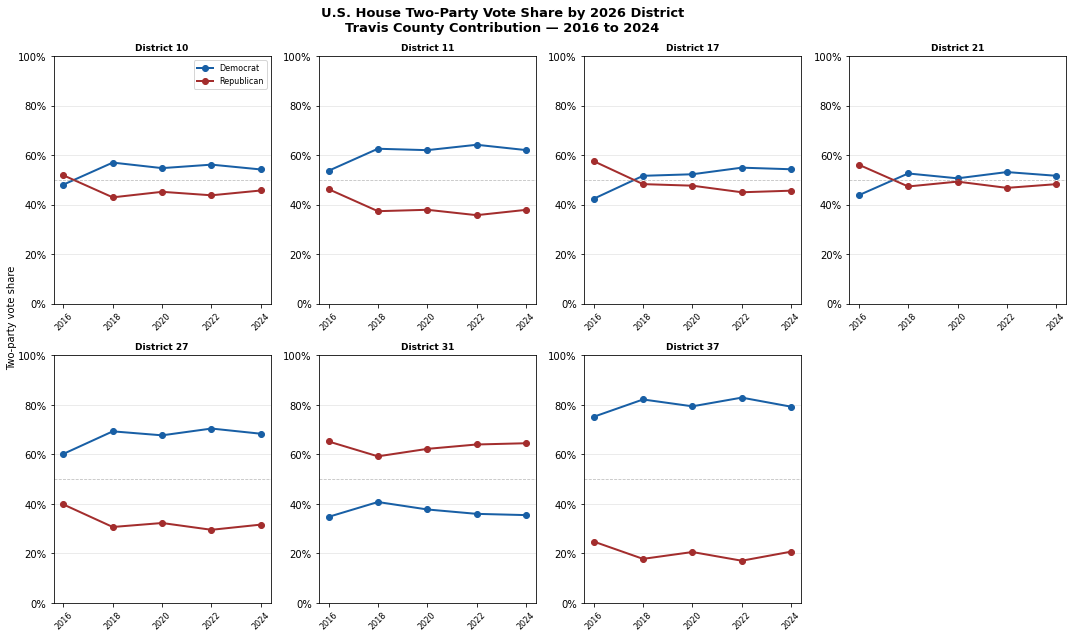

Saved figures


In [47]:
# Recalculate pivot including District 35
two_party = time_series[time_series['party'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
two_party_total = two_party.groupby(['year', 'new_district_id', 'party'])['estimated_votes'].sum().reset_index()

pivot = two_party_total.pivot_table(
    index=['year', 'new_district_id'], 
    columns='party', 
    values='estimated_votes'
).reset_index()
pivot.columns.name = None
pivot['total'] = pivot['DEMOCRAT'] + pivot['REPUBLICAN']
pivot['dem_share'] = pivot['DEMOCRAT'] / pivot['total'] * 100
pivot['rep_share'] = pivot['REPUBLICAN'] / pivot['total'] * 100

# Separate D35 from 2026 districts
pivot_35 = pivot[pivot['new_district_id'] == 35].copy()
pivot_2026 = pivot[pivot['new_district_id'] != 35].copy()

districts_2026 = sorted(pivot_2026['new_district_id'].unique())
years = sorted(pivot['year'].unique())

# Main figure — 2026 districts (2 rows x 4 cols, last cell empty)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, district in enumerate(districts_2026):
    ax = axes[i]
    d = pivot_2026[pivot_2026['new_district_id'] == district]
    
    ax.plot(d['year'], d['dem_share'], color='#185FA5', marker='o', linewidth=2, label='Democrat')
    ax.plot(d['year'], d['rep_share'], color='#A32D2D', marker='o', linewidth=2, label='Republican')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    ax.set_title(f'District {district}', fontweight='bold', fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].axis('off')

fig.text(0.07, 0.5, 'Two-party vote share', va='center', rotation='vertical', fontsize=10)

plt.suptitle('U.S. House Two-Party Vote Share by 2026 District\nTravis County Contribution — 2016 to 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0.07, 0, 1, 1])
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_vote_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Note: District 35 existed under the 2021 congressional map (PLANC2193).
# To plot D35 history, build a separate weights table using PLANC2193 boundaries.
# This is planned for a future notebook.

print("Saved figures")

## Step 10 — Maps

Choropleth maps showing U.S. House two-party vote share by 2026 congressional 
district within Travis County — 2016 to 2024.

Data represents Travis County voter contributions only, not full district results.

In [49]:
# =============================================================================
# STEP 10 — Maps
# =============================================================================

# Load 2026 districts and clip to Travis County boundary
travis_boundary = precincts_2020.dissolve()  # Dissolve all precincts into one Travis County shape
districts_clipped = gpd.clip(districts.to_crs(precincts_2020.crs), travis_boundary)

print(f"Clipped districts: {len(districts_clipped)}")
print(f"Districts: {sorted(districts_clipped['District'].unique())}")

Clipped districts: 7
Districts: [10, 11, 17, 21, 27, 31, 37]


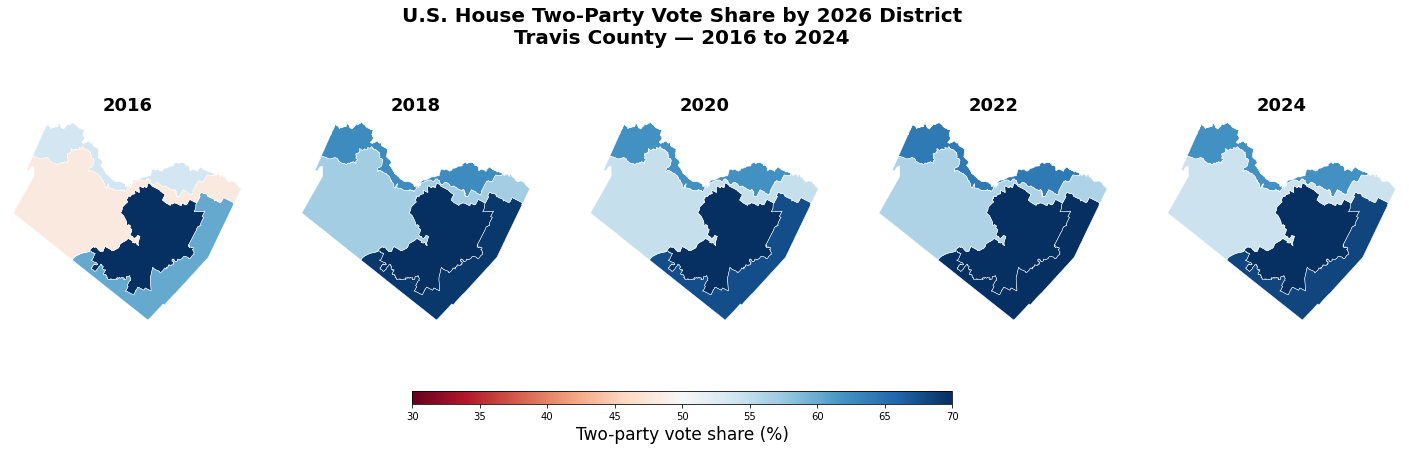

Saved map


In [90]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    year_data = pivot_2026[pivot_2026['year'] == year][['new_district_id', 'dem_share']].copy()
    year_data.columns = ['District', 'dem_share']
    
    districts_year = districts_clipped.merge(year_data, on='District', how='left')
    
    districts_year.plot(
        column='dem_share',
        ax=ax,
        cmap='RdBu',
        vmin=30,
        vmax=70,
        legend=False,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_title(f'{year}', fontweight='bold', fontsize=18)
    ax.set_axis_off()
    
    # Zoom into Travis County bounds
    bounds = districts_clipped.total_bounds
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=30, vmax=70))
sm.set_array([])
cbar_ax = fig.add_axes([0.35, 0.08, 0.3, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Two-party vote share (%)', fontsize=17)

plt.suptitle('U.S. House Two-Party Vote Share by 2026 District\nTravis County — 2016 to 2024',
             fontsize=20, fontweight='bold', y=1.0)

plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved map")

In [61]:
# =============================================================================
# Change map — 2016 to 2024 shift in Democrat two-party vote share
# =============================================================================

# Get 2016 and 2024 dem share
dem_2016 = pivot_2026[pivot_2026['year'] == 2016][['new_district_id', 'dem_share']].copy()
dem_2024 = pivot_2026[pivot_2026['year'] == 2024][['new_district_id', 'dem_share']].copy()

# Calculate delta
change = dem_2016.merge(dem_2024, on='new_district_id', suffixes=('_2016', '_2024'))
change['delta'] = change['dem_share_2024'] - change['dem_share_2016']
change.columns = ['District', 'dem_2016', 'dem_2024', 'delta']

print(change[['District', 'dem_2016', 'dem_2024', 'delta']].round(1).to_string())

   District  dem_2016  dem_2024  delta
0        10      48.1      54.2    6.1
1        11      53.7      62.1    8.4
2        17      42.4      54.3   11.9
3        21      43.8      51.7    7.9
4        27      60.2      68.4    8.1
5        31      34.8      35.5    0.7
6        37      75.2      79.3    4.1


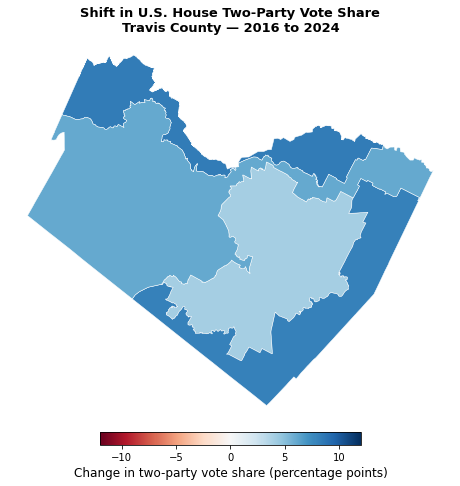

Saved change map


In [93]:
# Build change map
districts_change = districts_clipped.merge(change, on='District', how='left')

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

districts_change.plot(
    column='delta',
    ax=ax,
    cmap='RdBu',
    vmin=-12,
    vmax=12,
    legend=False,
    edgecolor='white',
    linewidth=0.5
)

ax.set_axis_off()

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=-12, vmax=12))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02)
cbar.set_label('Change in two-party vote share (percentage points)', fontsize=12)

plt.title('Shift in U.S. House Two-Party Vote Share\nTravis County — 2016 to 2024',
          fontsize=13, fontweight='bold')

plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_change_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved change map")

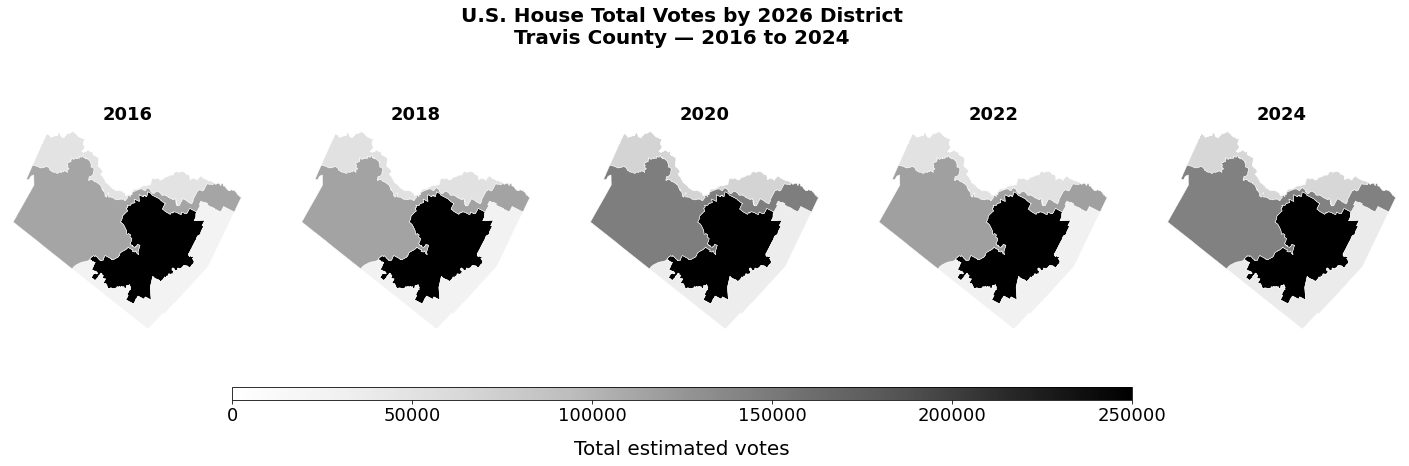

Saved turnout map


In [126]:
# =============================================================================
# Turnout map — total estimated votes per district per year
# =============================================================================

turnout = time_series.groupby(['year', 'new_district_id'])['estimated_votes'].sum().reset_index()
turnout.columns = ['year', 'District', 'total_votes']

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    year_data = turnout[turnout['year'] == year][['District', 'total_votes']].copy()
    districts_year = districts_clipped.merge(year_data, on='District', how='left')
    
    districts_year.plot(
        column='total_votes',
        ax=ax,
        cmap='Greys',
        vmin=0,
        vmax=250000,
        legend=False,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_title(f'{year}', fontweight='bold', fontsize=18)
    ax.set_axis_off()
    
    bounds = districts_clipped.total_bounds
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=0, vmax=250000))
sm.set_array([])
#cbar_ax = fig.add_axes([0.35, 0.12, 0.3, 0.03])
#cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
#cbar.set_label('Total estimated votes', fontsize=17)

cbar_ax = fig.add_axes([0.25, 0.11, 0.5, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Total estimated votes', fontsize=20, labelpad = 15)

plt.suptitle('U.S. House Total Votes by 2026 District\nTravis County — 2016 to 2024',
             fontsize=20, fontweight='bold', y=1.02)

plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_turnout_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved turnout map")